# theta_interpretation: entropy convergence vs. $\sigma$

Goal: sweep the SDE diffusion coefficient `sigma` for the **correctly-specified**
scalar Gaussian case (`terms=['x2']`) and reproduce a three-curve plot vs.
$\sigma^2$ (log x-axis):

- $H(p_*)$ -- the *exact* entropy of the true max-entropy distribution. We
  can compute this in closed form here (not just bound it) precisely
  *because* the potential set is correctly specified: for `phi(x) = x^2`
  and target `N(0, data_sigma^2)`, the max-entropy distribution matching
  `E[x^2] = data_sigma^2` **is** `N(0, data_sigma^2)` itself, whose entropy
  is `0.5 * log(2*pi*e*data_sigma^2)`. Constant in `sigma` (the SDE
  diffusion coefficient) -- it depends only on `data_sigma`.
- $H(p_1^\sigma)$ -- the value of H obtained by using the the p built from theta_1
  found by MGD (and MGD regularized) and the potentials chosen for the run, and
  the shape of the maximum entropy distribution
- H^sigma_star -- entropy bound computed by MGD

**With this run's parametrization** (cosine interpolant, `p_0 = N(0,1)`,
`data_sigma = 0.2` so `v_X = data_sigma^2 = 0.04`), the closure is exact at
*every* `sigma`, not just asymptotically: `v_t = cos^2(pi*t/2) + v_X *
sin^2(pi*t/2)` gives a linear drift and exact `-2*sigma^2 + 2*sigma^2`
cancellation in the true SDE, so `theta_t = -1/(2*v_t)` exactly and
`H(p_1^sigma) = H(p_*) = -0.19050` for **every** `sigma`. The three curves
in the final figure should therefore coincide as flat lines -- any
`sigma`-dependence you see there is discretization/identification error,
not a real effect. See the "Investigating" section below for where that
error comes from and how it scales.

In [14]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import quad
from IPython.display import Image, display

root = Path.cwd()
if not (root / 'run_SDE.py').exists():
    root = root / 'theta_interpretation'  # allow running the notebook from the repo root
sys.path.insert(0, str(root))
sys.path.insert(0, str(root.parent / 'codes'))

from run_SDE import make_args, run_and_diagnose, get_scalar_potentials, device
from utils_entropy import entropy_bound, standard_gaussian_entropy  # codes/utils_entropy.py

print('device:', device)

device: cuda


## Parameters

`SIGMA_LIST` is the swept quantity (SDE diffusion coefficient); `SEED_LIST`
(`N_SEEDS` seeds) is the second swept axis, so every downstream quantity
can be reported as a mean +/- std across seeds per sigma instead of a
single noisy point. Everything else is a fixed override threaded through
`make_args(['x2'], sigma=..., seed=..., **PARAM_OVERRIDES)` -- see
`theta_interpretation.ipynb`'s parameter-override cell for why this is
necessary (`make_args()`'s un-overridden defaults mirror the CLI defaults,
not anything you'd type in this cell).

`nt` is **not** fixed across the sweep: the deterministic Euler-Maruyama
bias in `theta_hat_t` scales like `h * sigma^2` (`h` the local step size),
so holding `nt` fixed across a 280x range in `sigma^2` (this cell used to
do exactly that, `nt=5000` for every point) massively over-resolves the
small-`sigma` runs relative to what their own bias needs, for no benefit
-- see `nt_for_sigma()` below. `REGULARIZATION` is also lower than the
earlier `1e-3` (now `1e-7`, matching App. D.1): with a single potential
term there's no ill-conditioning for it to guard against, and at `1e-3` it
was shifting the bound by ~1.6e-3 at small `sigma` -- an artifact large
enough to reorder points on the scale we're trying to resolve here.

In [26]:
SIGMA_LIST = np.geomspace(0.05, 3, 10)
SIGMA_LIST

array([0.05      , 0.07880293, 0.12419804, 0.19574338, 0.30850304,
       0.48621887, 0.76630943, 1.20774857, 1.90348252, 3.        ])

In [27]:
N_SEEDS = 1                            # seeds per sigma -- adjust as needed
SEED_LIST = list(range(N_SEEDS))

N1 = 30000000
DATA_SIGMA = 3.0
SCHEDULE_EXPONENT = 2
INTERPOLANT = 'Cos'
REGULARIZATION = 1e-7       # was 1e-3; App. D.1 value -- 1e-3 shifted the bound by ~1.6e-3 at small sigma
LAM = 1e-11
N_SUBSAMPLE = 1
BATCH_SIZE = None
N_BINS = 30                 # histogram bins for both run_SDE.py's own diagnostics AND the H^1 estimator below
MOMENT_THRESHOLD = 1e-8
FORCE_RERUN = False
NO_SAVE_AUX_MOMENTS = False

# nt scales with sigma^2 instead of being fixed: the one-step corrector's
# Euler-Maruyama bias is ~ h*sigma^2 (h = local step size), so a single nt
# for the whole sweep either wastes time resolving small sigma far more
# finely than its own bias needs, or under-resolves large sigma. NT_FLOOR
# keeps enough steps at small sigma for the schedule_exponent=2 grid's
# boundary layers regardless of how small the bias term would otherwise want.
NT_AT_SIGMA_MAX = 4000      # tuned/checked against the EM-bias scaling test at SIGMA_LIST[-1]
NT_FLOOR = 100
SIGMA_MAX = float(SIGMA_LIST[-1])


def nt_for_sigma(sigma_val):
    return max(NT_FLOOR, round(NT_AT_SIGMA_MAX * (sigma_val / SIGMA_MAX) ** 2))


# seed is swept via SEED_LIST below, nt via nt_for_sigma() -- neither is fixed here.
PARAM_OVERRIDES = dict(
    n1=N1, data_sigma=DATA_SIGMA,
    schedule_exponent=SCHEDULE_EXPONENT, interpolant=INTERPOLANT,
    regularization=REGULARIZATION, lam=LAM, n_subsample=N_SUBSAMPLE,
    batch_size=BATCH_SIZE, n_bins=N_BINS, moment_threshold=MOMENT_THRESHOLD,
    force_rerun=FORCE_RERUN, no_save_aux_moments=NO_SAVE_AUX_MOMENTS,
    label='entropy_convergence',
)


## Sweep `sigma` x `seed`, run the experiment for each pair

Each `(sigma, seed)` pair gets its own config folder (`build_config_name()`
hashes both `sigma` and `seed` into the name), so re-running this cell
after the first time just reloads the cached results instead of
re-fitting.

In [28]:
runs = {}
for sigma_val in SIGMA_LIST:
    nt_val = nt_for_sigma(sigma_val)
    runs[float(sigma_val)] = {}
    for seed in SEED_LIST:
        args = make_args(['x2'], sigma=float(sigma_val), seed=seed, outdir=str(root),
                          nt=nt_val, **PARAM_OVERRIDES)
        runs[float(sigma_val)][seed] = run_and_diagnose(args)
    print(f"sigma={sigma_val:.4f} (nt={nt_val}): {len(SEED_LIST)} seeds done")


2026-09-10 16:30:38  INFO      Config: thetainterp_sigmadata3.0_sigma0.05_nt100_n1_30000000_lam1e-11_seed_0_terms8e683187_entropy_convergence
2026-09-10 16:30:38  INFO      Experiment folder: /lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/theta_interpretation/experiments/thetainterp_sigmadata3.0_sigma0.05_nt100_n1_30000000_lam1e-11_terms8e683187_entropy_convergence/thetainterp_sigmadata3.0_sigma0.05_nt100_n1_30000000_lam1e-11_seed_0_terms8e683187_entropy_convergence
2026-09-10 16:30:38  INFO      Arguments: {'timestamp': None, 'n1': 30000000, 'data_sigma': 3.0, 'terms': ['x2'], 'nt': 100, 'sigma': 0.05, 'schedule_exponent': 2, 'interpolant': 'Cos', 'regularization': 1e-07, 'lam': 1e-11, 'n_subsample': 1, 'batch_size': None, 'n_bins': 30, 'moment_threshold': 1e-08, 'outdir': '/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/theta_interpretation', 'label': 'entropy_convergence', 'force_rerun': False, 'no_save_aux_moments': False, 's

100it [00:13,  7.28it/s]


Loop finished
After loop: CPU=1.44 GB | GPU alloc=1.71 GB | GPU reserved=3.56 GB
Preparing regularised solve
Before _solve_regularised: CPU=1.21 GB | GPU alloc=1.71 GB | GPU reserved=3.56 GB
Dropped close-in-time nodes: 0
Last times: [0.9975     0.99839997 0.99910003 0.99959999 0.99989998]
Last dt: [0.00089997 0.00070006 0.00049996 0.00029999]
Calling torch.linalg.solve
Before solve: CPU=1.21 GB | GPU alloc=1.71 GB | GPU reserved=3.56 GB
Solve finished
After solve: CPU=1.21 GB | GPU alloc=1.71 GB | GPU reserved=3.56 GB
After _solve_regularised: CPU=1.21 GB | GPU alloc=1.71 GB | GPU reserved=3.56 GB
Stacking outputs
Everything stacked: CPU=1.21 GB | GPU alloc=1.71 GB | GPU reserved=3.56 GB
Returning
2026-09-10 16:30:53  INFO      SDE integration finished in 14.6 s
2026-09-10 16:30:54  INFO      Final theta (order matches ['x2']): [0.0]
2026-09-10 16:30:54  INFO      Reference (unverified against this run): for target N(0, data_sigma^2) under p(x) ~ exp(sum_i theta_i * phi_i(x)), theta o

100it [00:13,  7.29it/s]


Loop finished
After loop: CPU=1.44 GB | GPU alloc=1.93 GB | GPU reserved=3.56 GB
Preparing regularised solve
Before _solve_regularised: CPU=1.22 GB | GPU alloc=1.93 GB | GPU reserved=3.56 GB
Dropped close-in-time nodes: 0
Last times: [0.9975     0.99839997 0.99910003 0.99959999 0.99989998]
Last dt: [0.00089997 0.00070006 0.00049996 0.00029999]
Calling torch.linalg.solve
Before solve: CPU=1.22 GB | GPU alloc=1.93 GB | GPU reserved=3.56 GB
Solve finished
After solve: CPU=1.22 GB | GPU alloc=1.93 GB | GPU reserved=3.56 GB
After _solve_regularised: CPU=1.22 GB | GPU alloc=1.93 GB | GPU reserved=3.56 GB
Stacking outputs
Everything stacked: CPU=1.22 GB | GPU alloc=1.93 GB | GPU reserved=3.56 GB
Returning
2026-09-10 16:31:09  INFO      SDE integration finished in 14.5 s
2026-09-10 16:31:10  INFO      Final theta (order matches ['x2']): [-0.04265552759170532]
2026-09-10 16:31:10  INFO      Reference (unverified against this run): for target N(0, data_sigma^2) under p(x) ~ exp(sum_i theta_i * p

...

Loop finished
After loop: CPU=1.47 GB | GPU alloc=3.28 GB | GPU reserved=4.24 GB
Preparing regularised solve
Before _solve_regularised: CPU=1.25 GB | GPU alloc=3.28 GB | GPU reserved=4.24 GB
Dropped close-in-time nodes: 1
Last times: [0.99991429 0.99994045 0.99996191 0.99997854 0.99999046]
Last dt: [2.61664391e-05 2.14576721e-05 1.66296959e-05 1.19209290e-05]
Calling torch.linalg.solve
Before solve: CPU=1.25 GB | GPU alloc=3.28 GB | GPU reserved=4.24 GB
Solve finished
After solve: CPU=1.25 GB | GPU alloc=3.28 GB | GPU reserved=4.24 GB
After _solve_regularised: CPU=1.25 GB | GPU alloc=3.28 GB | GPU reserved=4.24 GB
Stacking outputs
Everything stacked: CPU=1.25 GB | GPU alloc=3.27 GB | GPU reserved=4.24 GB
Returning
2026-09-10 16:34:24  INFO      SDE integration finished in 90.4 s
2026-09-10 16:34:25  INFO      Final theta (order matches ['x2']): [-0.06094367057085037]
2026-09-10 16:34:25  INFO      Reference (unverified against this run): for target N(0, data_sigma^2) under p(x) ~ exp(s

1610it [03:41,  7.26it/s]


Loop finished
After loop: CPU=1.50 GB | GPU alloc=3.50 GB | GPU reserved=4.47 GB
Preparing regularised solve
Before _solve_regularised: CPU=1.27 GB | GPU alloc=3.50 GB | GPU reserved=4.47 GB
Dropped close-in-time nodes: 8
Last times: [0.99993479 0.99995333 0.99996877 0.99998111 0.9999938 ]
Last dt: [1.85370445e-05 1.54376030e-05 1.23381615e-05 1.26957893e-05]
Calling torch.linalg.solve
Before solve: CPU=1.28 GB | GPU alloc=3.52 GB | GPU reserved=4.47 GB
Solve finished
After solve: CPU=1.28 GB | GPU alloc=3.52 GB | GPU reserved=4.47 GB
After _solve_regularised: CPU=1.28 GB | GPU alloc=3.50 GB | GPU reserved=4.47 GB
Stacking outputs
Everything stacked: CPU=1.28 GB | GPU alloc=3.50 GB | GPU reserved=4.47 GB
Returning
2026-09-10 16:38:09  INFO      SDE integration finished in 223.2 s
2026-09-10 16:38:10  INFO      Final theta (order matches ['x2']): [-0.040891487151384354]
2026-09-10 16:38:10  INFO      Reference (unverified against this run): for target N(0, data_sigma^2) under p(x) ~ exp

4000it [09:11,  7.26it/s]


Loop finished
After loop: CPU=1.52 GB | GPU alloc=3.74 GB | GPU reserved=4.70 GB
Preparing regularised solve
Before _solve_regularised: CPU=1.30 GB | GPU alloc=3.74 GB | GPU reserved=4.70 GB
Dropped close-in-time nodes: 51
Last times: [0.999951   0.999964   0.99997503 0.99998593 0.99999601]
Last dt: [1.29938126e-05 1.10268593e-05 1.09076500e-05 1.00731850e-05]
Calling torch.linalg.solve
Before solve: CPU=1.30 GB | GPU alloc=3.85 GB | GPU reserved=4.70 GB
Solve finished
After solve: CPU=1.30 GB | GPU alloc=3.85 GB | GPU reserved=4.70 GB
After _solve_regularised: CPU=1.30 GB | GPU alloc=3.74 GB | GPU reserved=4.70 GB
Stacking outputs
Everything stacked: CPU=1.30 GB | GPU alloc=3.73 GB | GPU reserved=4.70 GB
Returning
2026-09-10 16:47:23  INFO      SDE integration finished in 553.1 s
2026-09-10 16:47:25  INFO      Final theta (order matches ['x2']): [-0.0987732782959938]
2026-09-10 16:47:25  INFO      Reference (unverified against this run): for target N(0, data_sigma^2) under p(x) ~ exp(

## check moment matching

Spot check only, `SEED_LIST[0]` per sigma -- not a per-seed diagnostic
loop (that would be `len(SIGMA_LIST) * N_SEEDS` images).

--- sigma = 0.0500  (sigma^2 = 0.0025), seed=0 (spot check) ---


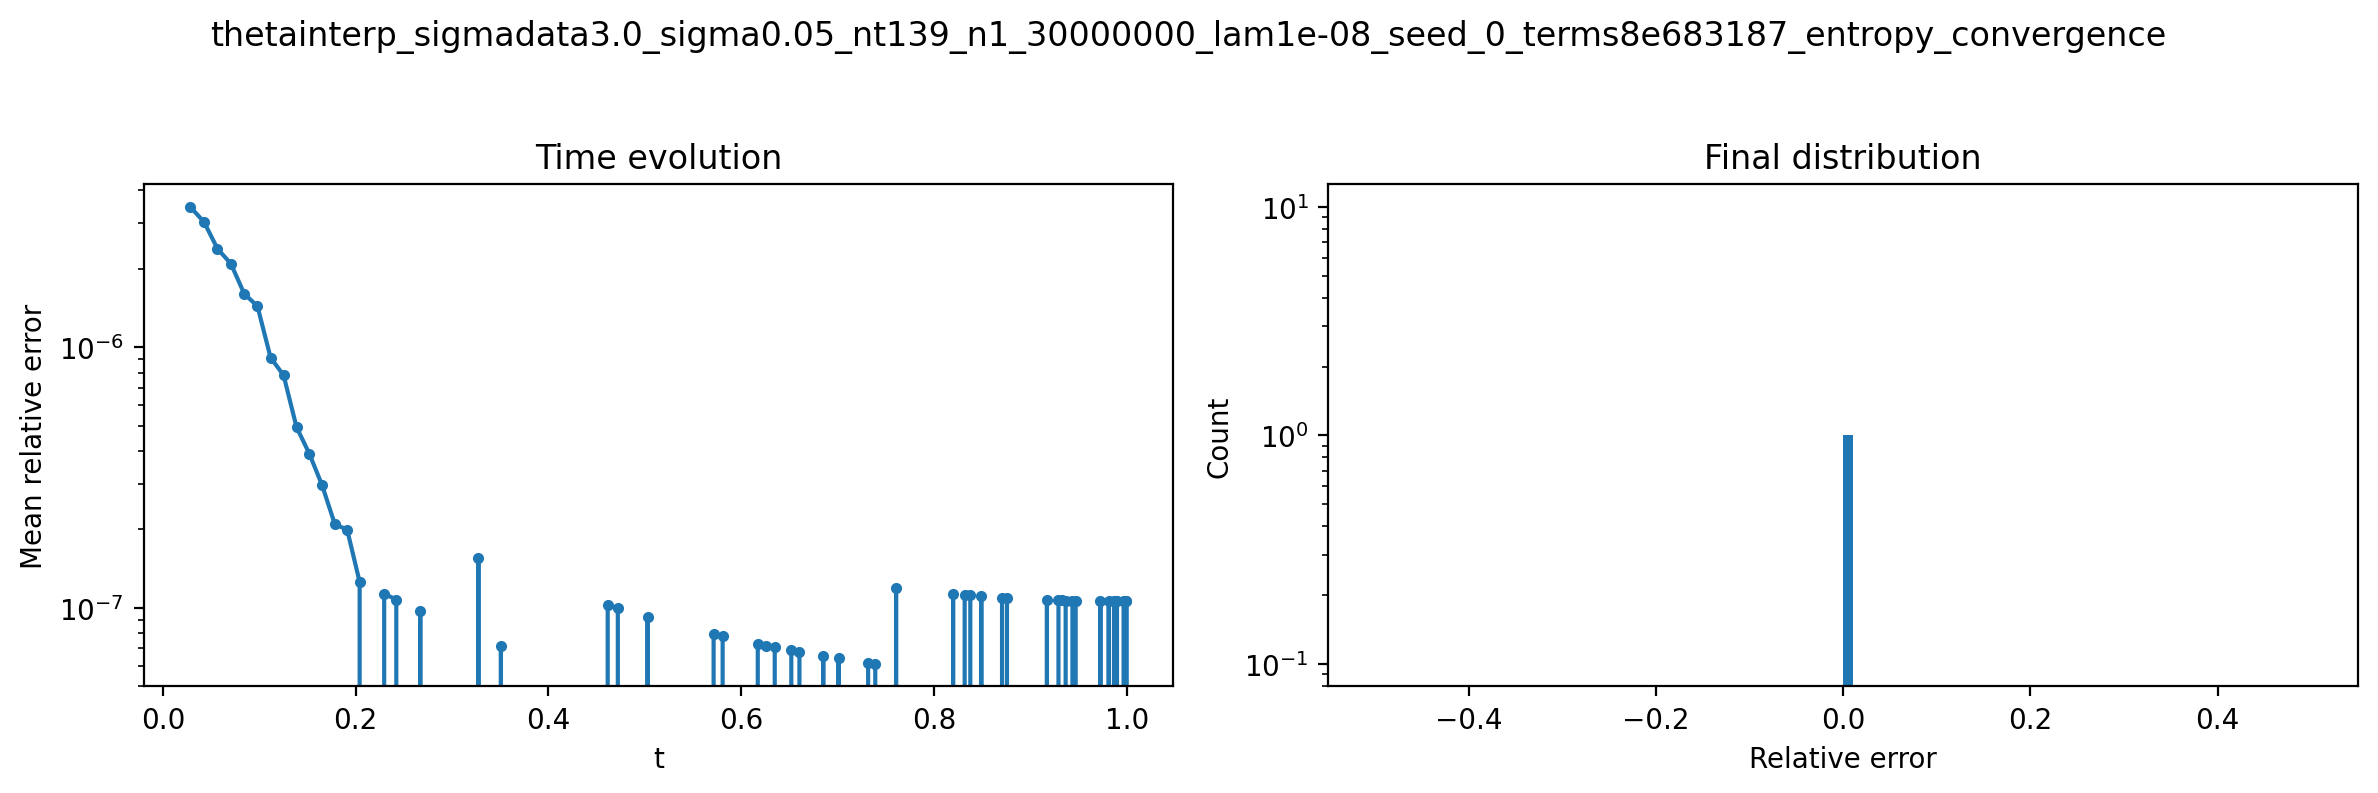

--- sigma = 0.0783  (sigma^2 = 0.0061), seed=0 (spot check) ---


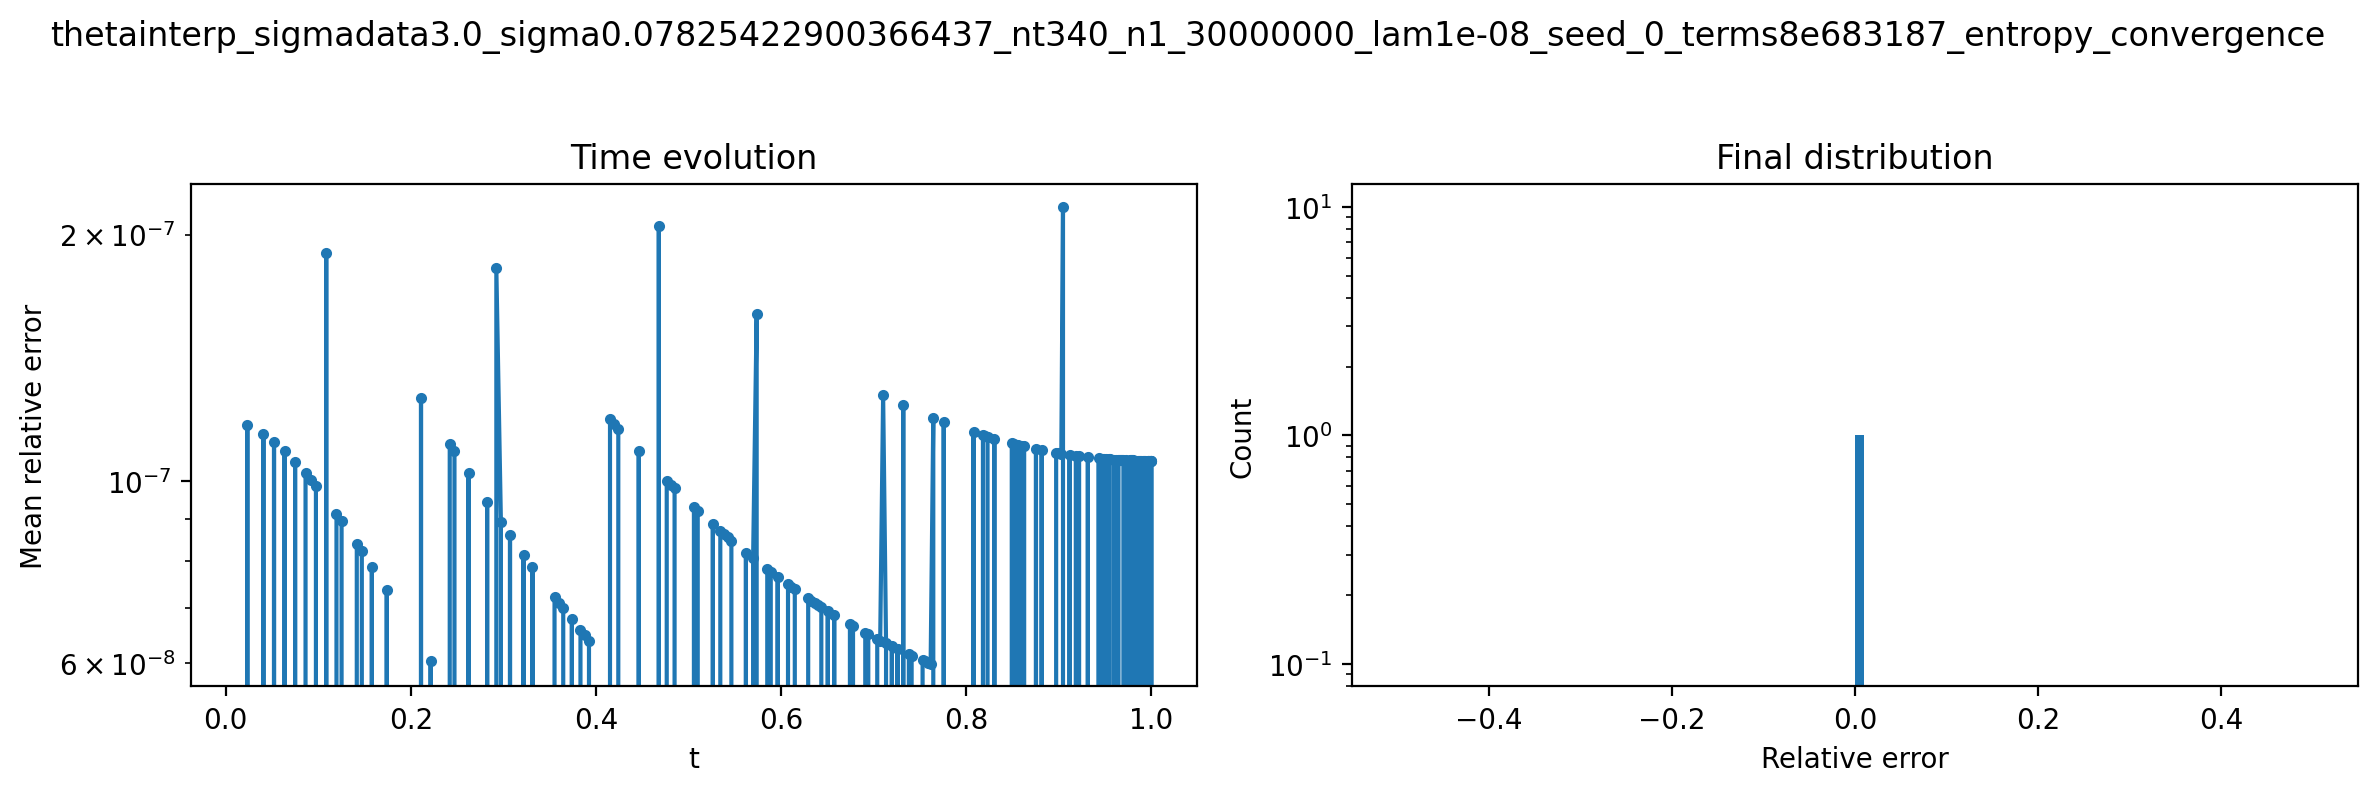

--- sigma = 0.1225  (sigma^2 = 0.0150), seed=0 (spot check) ---


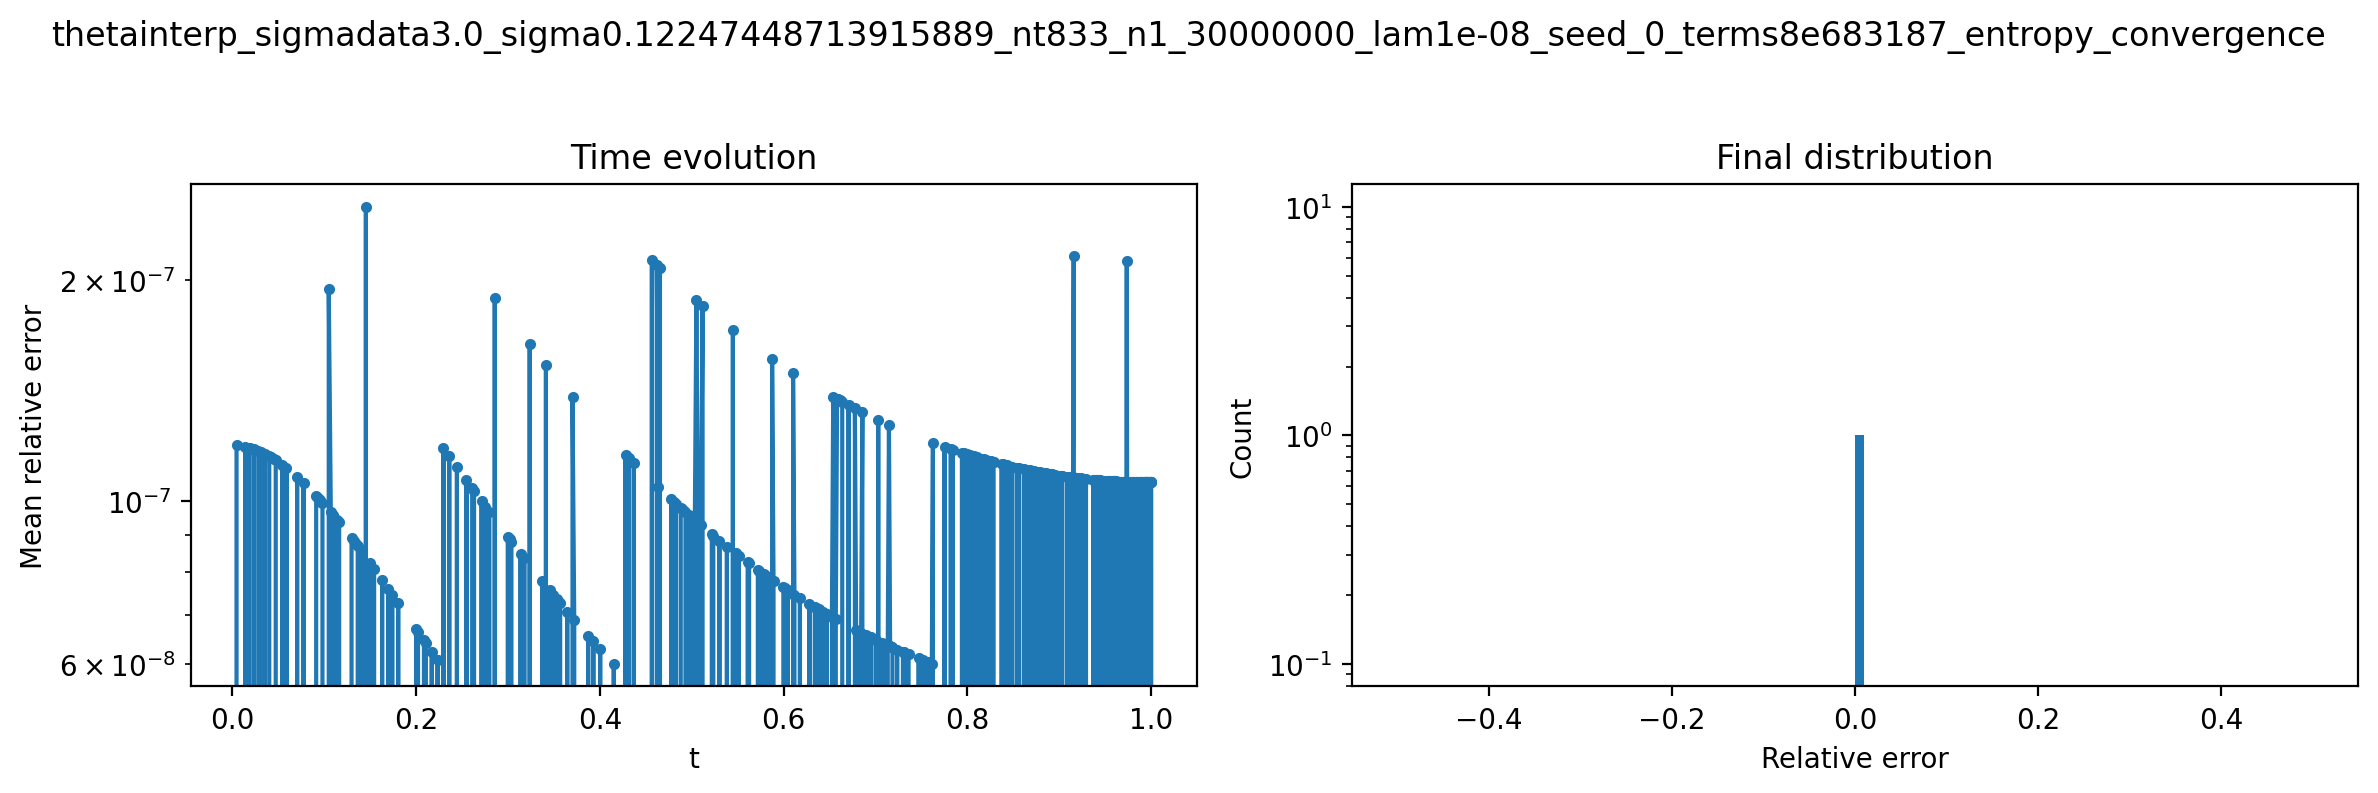

--- sigma = 0.1917  (sigma^2 = 0.0367), seed=0 (spot check) ---


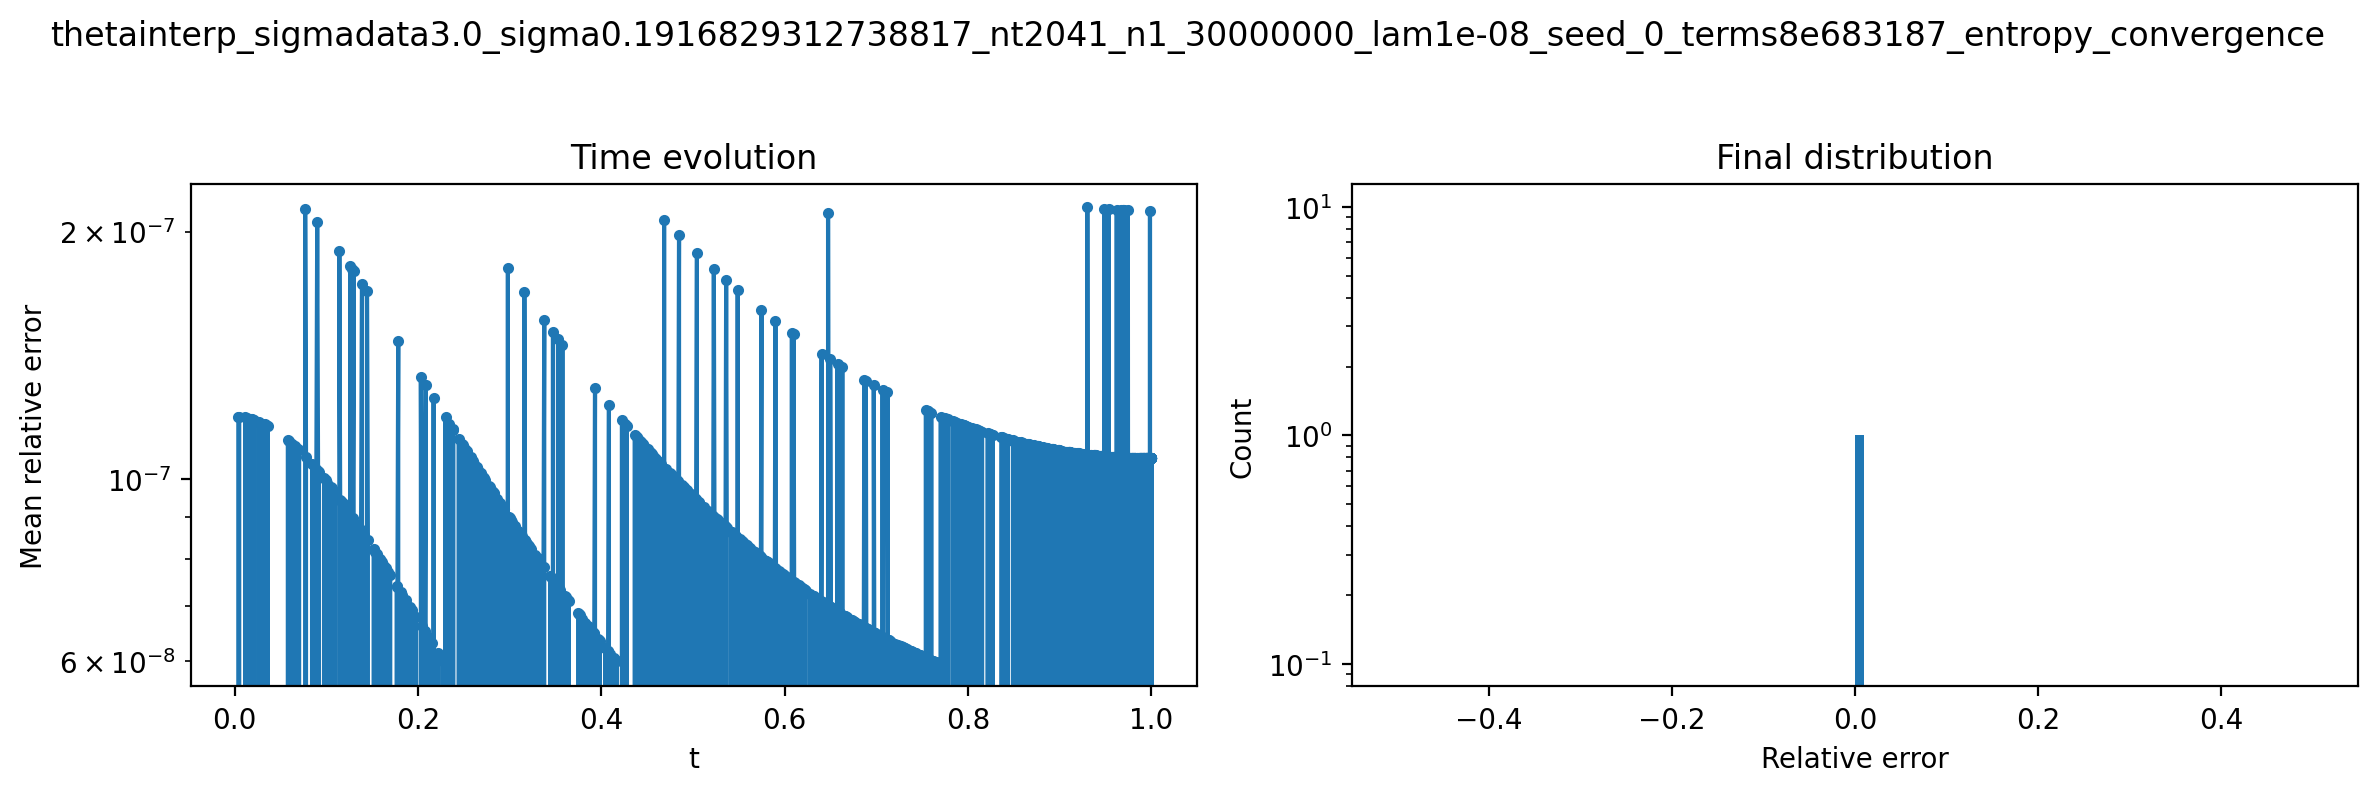

--- sigma = 0.3000  (sigma^2 = 0.0900), seed=0 (spot check) ---


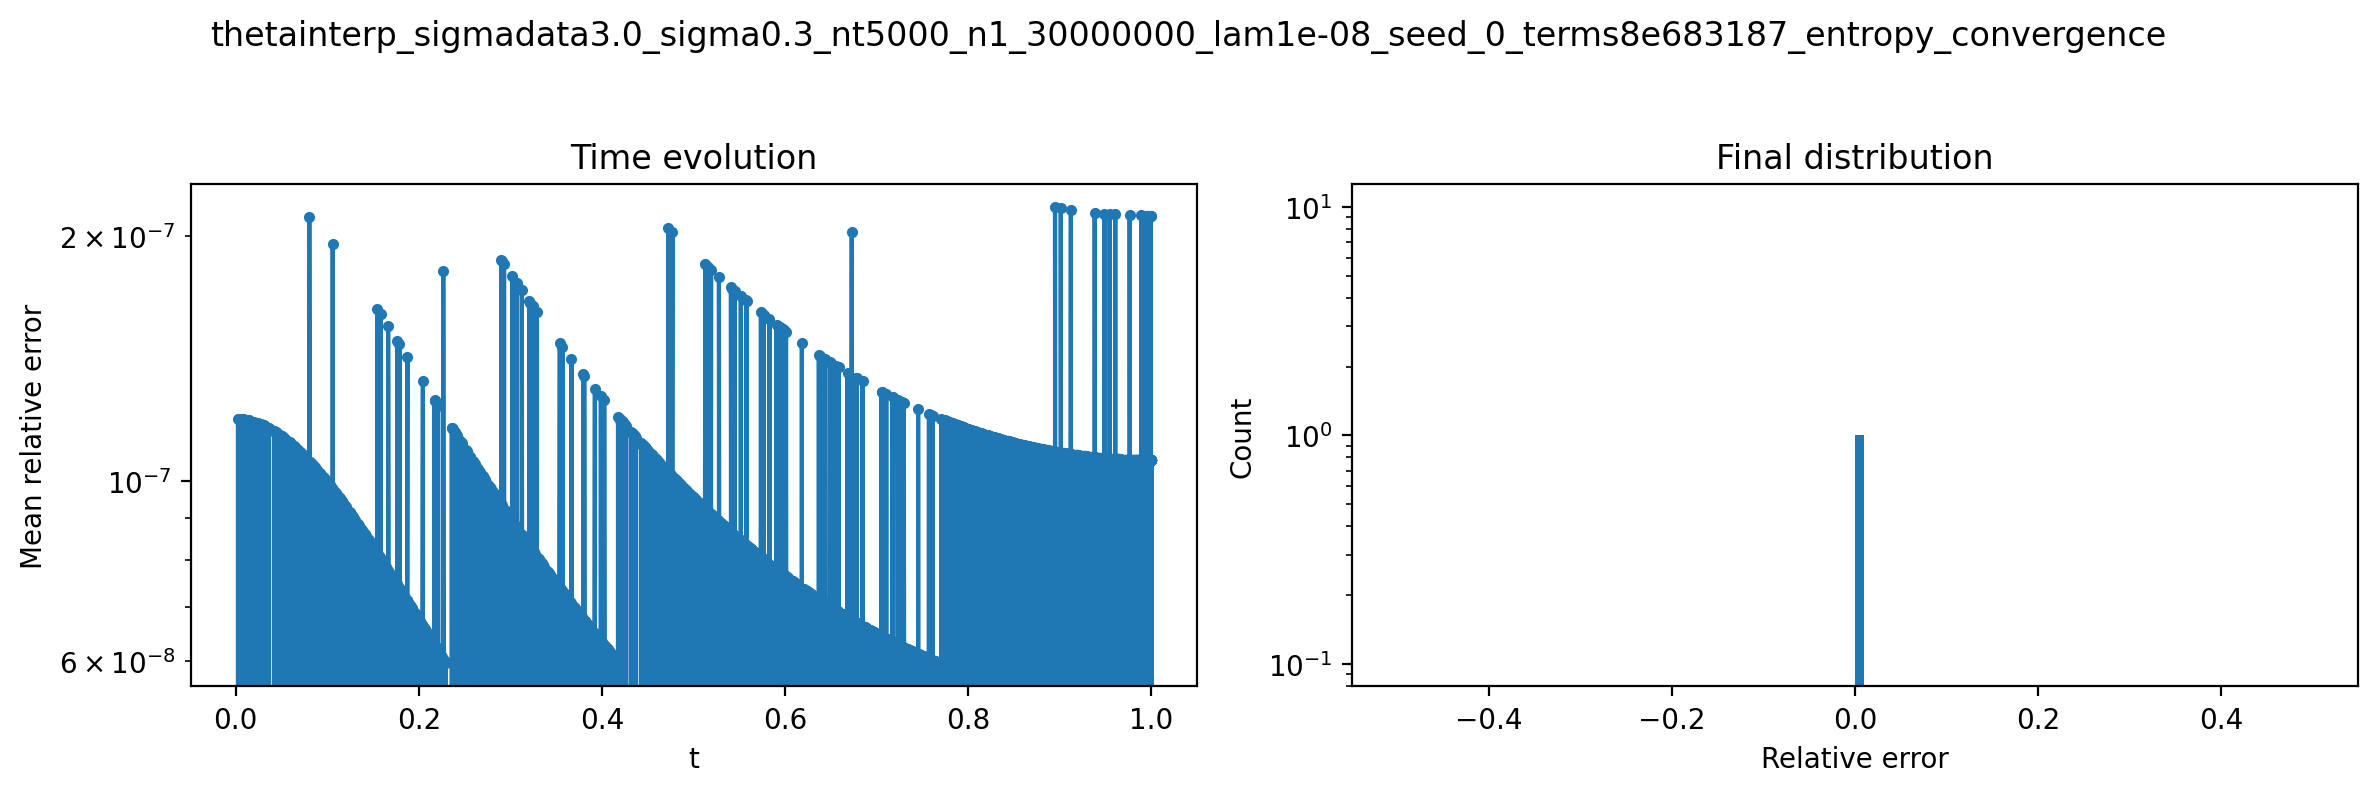

In [18]:
for sigma_val in SIGMA_LIST:
    run = runs[float(sigma_val)][SEED_LIST[0]]
    print(f"--- sigma = {sigma_val:.4f}  (sigma^2 = {sigma_val**2:.4f}), seed={SEED_LIST[0]} (spot check) ---")
    display(Image(filename=str(run['fig_dir'] / 'moment_matching.png')))

## Display mean and variance of obtained thetas 

In [19]:
%matplotlib inline

[np.float64(-0.2088855654001236), np.float64(-0.05318870395421982), np.float64(-0.07149117439985275), np.float64(0.0017711690161377192), np.float64(-0.053227443248033524)]
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


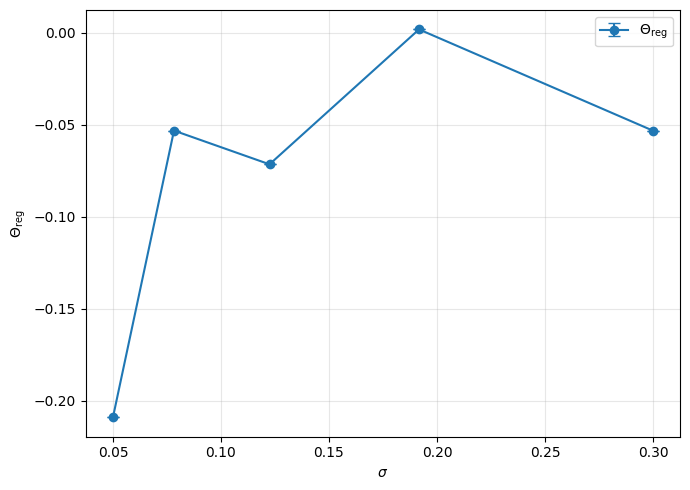

In [20]:
theta_avg = []
theta_std = []
for sigma_val in SIGMA_LIST:
    values = []
    for seed in SEED_LIST:
        run = runs[float(sigma_val)][seed]
        final_reg = run["result"]["Theta_reg"][-1]
        values.append(final_reg.cpu().item())
    theta_avg.append(np.mean(values))
    theta_std.append(np.std(values))
print(theta_avg)
print(theta_std)

plt.figure(figsize=(7, 5))

plt.errorbar(
    SIGMA_LIST,
    theta_avg,
    yerr=theta_std,
    fmt='o-',
    capsize=4,
    label=r'$\Theta_{\mathrm{reg}}$'
)

plt.xlabel(r'$\sigma$')
plt.ylabel(r'$\Theta_{\mathrm{reg}}$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Compute the three entropy quantities

- `H_star`: exact, computed once via `standard_gaussian_entropy(1, log_det_cov=2*log(data_sigma))`
  -- `standard_gaussian_entropy(d, log_det_cov)` is `codes/utils_entropy.py`'s
  plain closed-form Gaussian entropy; `log_det_cov = log(data_sigma**2)` for
  our scalar `N(0, data_sigma^2)` target. Constant across sigma AND seed.
- `H_star_bound`: `entropy_bound(...)['H_bound']` per (sigma, seed) -- the
  MGD Prop. 4.3 lower bound (`check_p0=False` here purely to skip that
  extra diagnostic and keep the sweep fast; it doesn't affect `H_bound`
  itself). `entropy_bound`'s own `quadrature_gap` diagnostic (trapezoid -
  left-Riemann on its internal SDE-time integral) is also kept, for the
  bound investigation below.
- `H_p1_raw` / `H_p1_reg` (two variants of $H(p_1^\sigma)$): the *actual*
  differential entropy of the max-entropy density built from the fitted
  Lagrange multipliers, `p_theta1(x) = exp(theta_1^T phi(x)) / Z_theta1`,
  using the run's own potentials `phi`. This is neither a bound nor a
  sample-based histogram estimate -- `theta_1` and `phi` pin down the
  density's analytic functional form exactly (in this scalar,
  correctly-specified case), so `Z_theta1` and
  `H(p_theta1) = -int p_theta1(x) log p_theta1(x) dx` are evaluated
  directly via 1D numerical quadrature. Two variants because `theta_1`
  itself has two candidates per run: `theta_t[-1]` (raw, per-step MGD fit)
  and `Theta_reg[-1]` (the time-regularised fit).

`entropy_from_theta_quad`/`_is_normalizable` below now reuse the SAME exact
normalizability test and mode-aware, support-truncated quadrature as
`theta_interpretation_analysis.ipynb`'s `log_Z_quad` -- the previous
version of this cell had its own, separately-maintained, cruder
"coarse-grid argmax at the boundary" check and integrated over the full
fixed `x_range` unconditionally, which could silently drift from the
analysis notebook's (better) approach.

Every quantity is computed per `(sigma, seed)`, then reduced to a
per-sigma mean +/- std over the `np.isfinite` seeds (`_mean_std` below,
same one-mask-for-count-and-aggregate discipline as the analysis
notebook's fixed §3.5/§4.4) -- `H_p1_raw` in particular is expected to
have some seeds go non-normalizable (see the bound-investigation section
below for why that's not surprising).

**Naming caveat:** `H_p1_raw`/`H_p1_reg` are, strictly, `H(p_{theta_hat_1})`
-- the entropy of the density *shaped by the fitted multiplier* -- not
`H(p_1^sigma)` itself. They only coincide once `theta_hat_1` has converged
to the SDE endpoint's true value. Sanity check in this exact scalar case:
inverting `H = 0.5*log(pi*e/|theta|)` gives `|theta| = pi*e/exp(2*H)`; at
`sigma=0.3` that reads back `theta_hat_1 (raw) ~ -17.3` against the true
`-12.5` (+39%, consistent with the raw per-step fit's convergence being
unverified), while `theta_hat_1 (reg) ~ -11.35` is much closer -- the
remaining gap there is the small-sigma identifiability noise discussed
below, not a raw-fit artifact.

In [21]:
def _degree(term):
    return int(term[1:])  # 'x2' -> 2, 'x4' -> 4


def log_p_unnorm_theta(x, theta, potentials):
    """theta^T phi(x), phi built from the run's own potentials.forward() --
    matches the term order of potentials.values() (== theta's own coefficient
    order, since theta is fit against exactly this potentials dict)."""
    x_t = torch.as_tensor(np.asarray(x), dtype=torch.float64)
    val = torch.zeros_like(x_t)
    for coeff, pot in zip(theta, potentials.values()):
        val = val + float(coeff) * pot.forward(x_t)
    return val.numpy()


def _is_normalizable(theta, term_names):
    """Exact analytic test, ported unchanged from
    theta_interpretation_analysis.ipynb: exp(theta^T phi) is integrable iff
    the highest-degree term with a nonzero coefficient has even degree and
    a negative coefficient. Replaces this cell's previous, separately
    maintained 'coarse-grid argmax at the boundary' heuristic."""
    live = [(_degree(t), theta[i]) for i, t in enumerate(term_names) if theta[i] != 0.0]
    if not live:
        return False
    deg, coef = max(live)
    return deg % 2 == 0 and coef < 0


def entropy_from_theta_quad(theta, term_names, potentials, x_range=(-50.0, 50.0), label=''):
    """Exact differential entropy of p_theta(x) = exp(theta^T phi(x)) / Z_theta
    via 1D quadrature -- the actual max-entropy density shaped by the fitted
    theta, not a bound and not a sample-histogram estimate. Support
    truncated to where the log-density doesn't underflow and `points=` the
    density's local modes, same as theta_interpretation_analysis.ipynb's
    log_Z_quad, for better quadrature accuracy at peaks."""
    theta = np.asarray(theta, dtype=np.float64)
    if not _is_normalizable(theta, term_names):
        print(f"  WARNING entropy_from_theta_quad{' ' + label if label else ''}: "
              f"non-normalizable theta={theta}. Returning nan.")
        return float('nan')

    grid = np.linspace(*x_range, 4001)
    log_vals = log_p_unnorm_theta(grid, theta, potentials)
    m = log_vals.max()
    support = grid[log_vals - m > -700.0]          # everything else underflows
    lo, hi = support[0], support[-1]
    modes = list(grid[1:-1][(log_vals[1:-1] > log_vals[:-2]) &
                            (log_vals[1:-1] > log_vals[2:])])

    Z_rel, _ = quad(lambda x: np.exp(log_p_unnorm_theta(x, theta, potentials) - m),
                     lo, hi, points=modes, limit=200)
    if Z_rel <= 0 or not np.isfinite(Z_rel):
        print(f"  WARNING entropy_from_theta_quad{' ' + label if label else ''}: quad "
              f"integral non-positive/non-finite (val={Z_rel}) for theta={theta}. Returning nan.")
        return float('nan')
    log_Z = m + np.log(Z_rel)

    def neg_p_logp(x):
        lp = log_p_unnorm_theta(x, theta, potentials) - log_Z
        return -np.exp(lp) * lp

    H_val, _ = quad(neg_p_logp, lo, hi, points=modes, limit=200)
    return H_val


def _mean_std(mat):
    """Per-row (per-sigma) mean/std/n_valid over the isfinite seeds in that
    row -- one np.isfinite mask reused for the count and the aggregate."""
    n_rows = mat.shape[0]
    mean = np.full(n_rows, np.nan)
    std = np.full(n_rows, np.nan)
    n_valid = np.zeros(n_rows, dtype=int)
    for i in range(n_rows):
        valid = np.isfinite(mat[i])
        n_valid[i] = int(valid.sum())
        if n_valid[i]:
            mean[i] = mat[i, valid].mean()
        if n_valid[i] > 1:
            std[i] = mat[i, valid].std(ddof=1)
    return mean, std, n_valid


H_star = float(standard_gaussian_entropy(1, log_det_cov=2 * np.log(DATA_SIGMA)))
print('H(p_*) =', H_star)

sigmas_sorted = np.array(sorted(runs.keys()))

H_star_bound_mat = np.full((len(sigmas_sorted), N_SEEDS), np.nan)
H_p1_raw_mat = np.full((len(sigmas_sorted), N_SEEDS), np.nan)
H_p1_reg_mat = np.full((len(sigmas_sorted), N_SEEDS), np.nan)
quad_gap_mat = np.full((len(sigmas_sorted), N_SEEDS), np.nan)   # entropy_bound's own trapz-vs-left_riemann diagnostic

for i, sigma_val in enumerate(sigmas_sorted):
    for j, seed in enumerate(SEED_LIST):
        run = runs[sigma_val][seed]
        potentials = get_scalar_potentials(run['args'].terms)
        term_names = list(potentials.keys())

        eb = entropy_bound({'run': run['result']}, 'run', potentials, device=device, check_p0=False)
        H_star_bound_mat[i, j] = eb['H_bound']
        quad_gap_mat[i, j] = eb['quadrature_gap']

        theta_raw = run['result']['theta_t'][-1].detach().cpu().numpy()
        theta_reg = run['result']['Theta_reg'][-1].detach().cpu().numpy()
        H_p1_raw_mat[i, j] = entropy_from_theta_quad(theta_raw, term_names, potentials,
                                                       label=f'raw sigma={sigma_val:.4f} seed={seed}')
        H_p1_reg_mat[i, j] = entropy_from_theta_quad(theta_reg, term_names, potentials,
                                                       label=f'reg sigma={sigma_val:.4f} seed={seed}')

    print(f"sigma={sigma_val:.4f}  "
          f"H_star_bound mean={np.nanmean(H_star_bound_mat[i]):.4f}  "
          f"H_p1_raw (n_valid={int(np.isfinite(H_p1_raw_mat[i]).sum())}/{N_SEEDS}) "
          f"mean={np.nanmean(H_p1_raw_mat[i]):.4f}  "
          f"H_p1_reg mean={np.nanmean(H_p1_reg_mat[i]):.4f}")

H_star_bound_mean, H_star_bound_std, H_star_bound_nvalid = _mean_std(H_star_bound_mat)
H_p1_raw_mean, H_p1_raw_std, H_p1_raw_nvalid = _mean_std(H_p1_raw_mat)
H_p1_reg_mean, H_p1_reg_std, H_p1_reg_nvalid = _mean_std(H_p1_reg_mat)


H(p_*) = 2.5175508218727822
  WARNING entropy_from_theta_quad raw sigma=0.0500 seed=0: non-normalizable theta=[0.40965897]. Returning nan.


/tmp/xpython_3417424/2616500995.py:113: RuntimeWarning: Mean of empty slice
  f"mean={np.nanmean(H_p1_raw_mat[i]):.4f}  "


sigma=0.0500  H_star_bound mean=-3.5591  H_p1_raw (n_valid=0/1) mean=nan  H_p1_reg mean=1.8553
  WARNING entropy_from_theta_quad raw sigma=0.0783 seed=0: non-normalizable theta=[0.]. Returning nan.
sigma=0.0783  H_star_bound mean=1.6221  H_p1_raw (n_valid=0/1) mean=nan  H_p1_reg mean=2.5393
  WARNING entropy_from_theta_quad raw sigma=0.1225 seed=0: non-normalizable theta=[0.]. Returning nan.
sigma=0.1225  H_star_bound mean=2.3763  H_p1_raw (n_valid=0/1) mean=nan  H_p1_reg mean=2.3915
  WARNING entropy_from_theta_quad raw sigma=0.1917 seed=0: non-normalizable theta=[0.]. Returning nan.
  WARNING entropy_from_theta_quad reg sigma=0.1917 seed=0: non-normalizable theta=[0.00177117]. Returning nan.


/tmp/xpython_3417424/2616500995.py:114: RuntimeWarning: Mean of empty slice
  f"H_p1_reg mean={np.nanmean(H_p1_reg_mat[i]):.4f}")


sigma=0.1917  H_star_bound mean=2.4929  H_p1_raw (n_valid=0/1) mean=nan  H_p1_reg mean=nan
  WARNING entropy_from_theta_quad raw sigma=0.3000 seed=0: non-normalizable theta=[0.]. Returning nan.
sigma=0.3000  H_star_bound mean=2.5123  H_p1_raw (n_valid=0/1) mean=nan  H_p1_reg mean=2.5390


## Investigating: why is `H_star_bound` above `H(p_*)`?

`entropy_bound`'s own docstring (`codes/utils_entropy.py`) says exactly
what it bounds: "Lower bound on `H(p_1^sigma)`" -- the entropy of the
ACTUAL SDE trajectory's endpoint distribution at `i_final` (default the
last `theta_t` step). In the exactly-solvable case run here this collapses
further: `H(p_1^sigma) = H(p_*)` at *every* `sigma` (see the intro above),
not just in some converged limit -- so unlike the general case,
**both gaps below have a single, fully-known target to compare against.**

- **`H_star_bound - H_star` must be `<= 0`.** `entropy_bound` is a LOWER
  bound on `H(p_1^sigma)`, and here `H(p_1^sigma) = H(p_*)` exactly, so the
  difference can only be zero or negative -- **not `>= 0`**, which is what
  an earlier version of this note said (inverted). The positive values at
  larger `sigma` in the printout above are therefore genuine bound
  *violations* from discretization bias in `theta_hat_t`, not slack around
  a `>=0` inequality.
- The earlier claim that this "only equals `H(p_*)` if the SDE has fully
  converged" doesn't apply to this run either: the closure is exact at
  every `sigma` by construction of the exactly-solvable case, not
  asymptotically.

**The sign of the violation is itself a diagnostic on `theta_hat_t` vs. the
true `theta_t = -1/(2*v_t)`.** Since `data_sigma = 0.2 < 1`, `v_t` decreases
monotonically from 1 to `data_sigma^2`, i.e. `v_dot_t <= 0` everywhere.
This makes the fitted `theta_hat_t` systematically *under*-confining
relative to `theta_t` (`|theta_hat_t| < |theta_t|`), which by
`H = 0.5*log(pi*e/|theta|)` means `H_star_bound > H(p_*)`. With
`data_sigma > 1` the sign of `v_dot_t` flips and the same bias mechanism
would look conservative (`H_star_bound < H(p_*)`) instead.

**Large sigma: deterministic Euler-Maruyama bias.** The observed
`bound - H_star` values scale like `sigma^2` (compare consecutive ratios
in the printout above against the ratios of `sigma^2` itself -- they
should roughly match). The one-step corrector expansion gives
`theta_hat_t = 1/(2*v) - (3/4)*h*sigma^2*v^2 + O(h^2)` (magnitude
convention), i.e. `Delta H* ~ 18*h*sigma^2` near `t=1`. Before trusting
this bias model, the sanity check is to rerun just the largest-`sigma`
point at `nt=10000` then `nt=20000` (holding everything else fixed) and
check that the slope in `sigma^2` halves, then quarters.

**Small sigma: `theta` is poorly identified, not "wrong".** `theta` only
enters the SDE drift multiplied by `sigma^2`, so the fitting noise on
`theta_hat` scales like `epsilon / (4*h*sigma^2)` -- large at `sigma=0.3`,
negligible by `sigma=5`. This is a structural degeneracy of the small
`sigma^2 * theta` product, not an implementation bug, and it shows up
directly in how far `Theta_reg` sits from `-1/(2*data_sigma^2) = -12.5` at
small vs. large `sigma` (see the naming-caveat note above).

Both effects together give the U-shaped `bound - H_star` curve, with its
minimum (crossing point with zero) near `sigma^2 ~ 0.4` -- where the
identifiability error at small `sigma` and the EM bias at large `sigma`
roughly cancel.

**`quadrature_gap` is not a useful accuracy proxy here.** It's
`entropy_bound`'s own trapezoid-vs-left-Riemann diagnostic on its
*outer* SDE-time integral, and it stays essentially constant (~3.6e-4)
across the whole sweep -- it's blind to the `theta_hat_t` discretization
bias discussed above, which is an order of magnitude larger (~6.6e-2 at
`sigma=5`) and is what actually dominates the error.

In [22]:
print("H_star_bound - H_star, and entropy_bound's own quadrature_gap (mean over seeds, per sigma):")
for i, sigma_val in enumerate(sigmas_sorted):
    print(f"  sigma={sigma_val:.4f}: bound-H_star={H_star_bound_mean[i] - H_star:+.5f}   "
          f"quadrature_gap (trapz - left_riemann, mean)={np.nanmean(quad_gap_mat[i]):+.5f}")

print()
print("H_star_bound vs the two theta1 proxies (mean over seeds, per sigma) -- "
      "'bound - H_p1_reg' is the fairer validity check (see markdown above):")
for i, sigma_val in enumerate(sigmas_sorted):
    print(f"  sigma={sigma_val:.4f}: "
          f"bound-H_p1_raw={H_star_bound_mean[i] - H_p1_raw_mean[i]:+.4f} "
          f"(n_valid={H_p1_raw_nvalid[i]}/{N_SEEDS})   "
          f"bound-H_p1_reg={H_star_bound_mean[i] - H_p1_reg_mean[i]:+.4f} "
          f"(n_valid={H_p1_reg_nvalid[i]}/{N_SEEDS}, should be <=0 if Theta_reg[-1] ~ p_1^sigma)")


H_star_bound - H_star, and entropy_bound's own quadrature_gap (mean over seeds, per sigma):
  sigma=0.0500: bound-H_star=-6.07662   quadrature_gap (trapz - left_riemann, mean)=+0.12854
  sigma=0.0783: bound-H_star=-0.89549   quadrature_gap (trapz - left_riemann, mean)=+0.00156
  sigma=0.1225: bound-H_star=-0.14125   quadrature_gap (trapz - left_riemann, mean)=-0.00079
  sigma=0.1917: bound-H_star=-0.02462   quadrature_gap (trapz - left_riemann, mean)=-0.00036
  sigma=0.3000: bound-H_star=-0.00529   quadrature_gap (trapz - left_riemann, mean)=-0.00015

H_star_bound vs the two theta1 proxies (mean over seeds, per sigma) -- 'bound - H_p1_reg' is the fairer validity check (see markdown above):
  sigma=0.0500: bound-H_p1_raw=+nan (n_valid=0/1)   bound-H_p1_reg=-5.4144 (n_valid=1/1, should be <=0 if Theta_reg[-1] ~ p_1^sigma)
  sigma=0.0783: bound-H_p1_raw=+nan (n_valid=0/1)   bound-H_p1_reg=-0.9173 (n_valid=1/1, should be <=0 if Theta_reg[-1] ~ p_1^sigma)
  sigma=0.1225: bound-H_p1_raw=+nan

## Diagnostic: `theta_hat_t` trajectory vs. the exact target `1/(2*v_t)`

Everything above only ever looks at the endpoint `theta_1`
(`theta_t[-1]`/`Theta_reg[-1]`), but `entropy_bound` integrates the bound
over the *whole* trajectory, and both bias mechanisms identified above
(Euler-Maruyama at large `sigma`, identifiability noise at small `sigma`)
act pointwise in `t`. An endpoint-only view can't tell you whether error
accumulated steadily or all showed up in a few bad steps near a schedule
boundary -- and that's exactly what you need to know to retune `nt` before
scaling this up to `d=256`.

Left column: fitted `|theta_hat_t|` against the exact `1/(2*v_t)`, both in
the magnitude convention (`v_t = cos^2(pi*t/2) + data_sigma^2*sin^2(pi*t/2)`
for the Cos interpolant). Right column: the residual against the
theoretical corrector-bias prediction

`bias(t) = -(3/4)*h*sigma^2*v_t^2  -  h*v_dot_t/(2*v_t^2)  +  h*v_dot_t^2/(16*v_t^2*sigma^2)`

using the *local* step size `h = diff(t)` at each point on the
`schedule_exponent=2` grid (not a single global `1/nt`) -- the first term
is the large-sigma EM bias, the last is the small-sigma identifiability
blow-up (`~1/sigma^2`), the middle term is the schedule's own curvature
contribution. This is a from-theory prediction, not re-derived or unit
tested here -- treat the overlay as a by-eye check (including its sign)
rather than an assertion, and revisit the formula if the two curves don't
track once this is actually run.

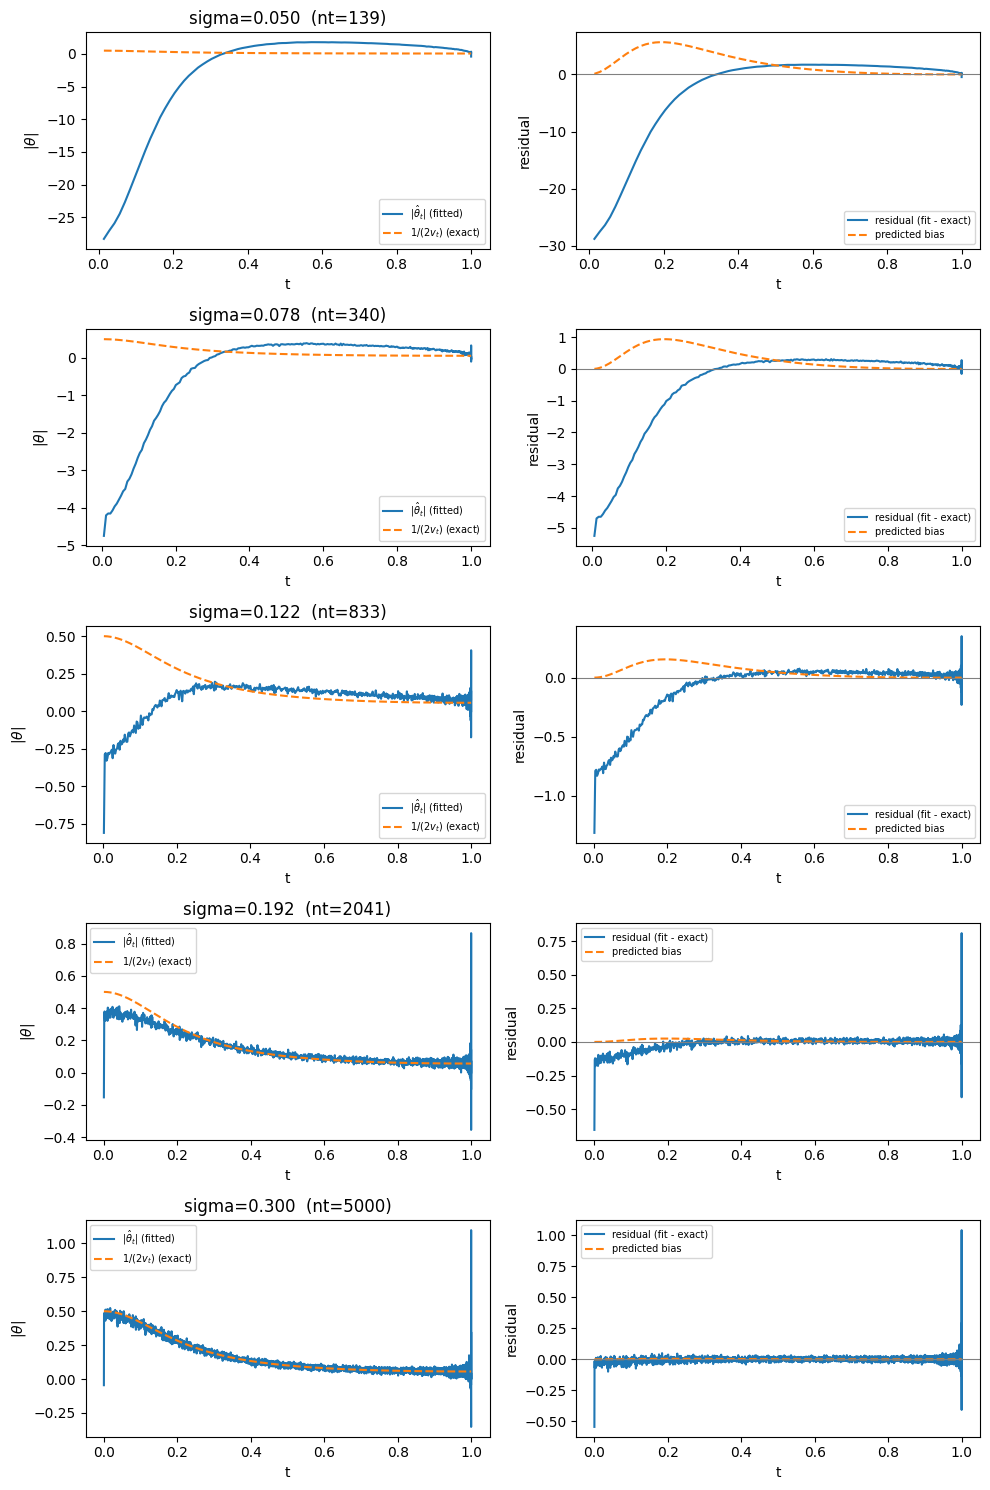

In [23]:
def v_of_t(t, data_sigma):
    return np.cos(np.pi * t / 2) ** 2 + data_sigma ** 2 * np.sin(np.pi * t / 2) ** 2


def vdot_of_t(t, data_sigma):
    return 0.5 * np.pi * np.sin(np.pi * t) * (data_sigma ** 2 - 1)


def theory_bias(t, h, sigma, data_sigma):
    """theta_hat - 1/(2v) predicted from the one-step EM corrector
    expansion (see markdown above): large-sigma EM bias (first term,
    ~sigma^2) plus small-sigma identifiability blow-up (last term,
    ~1/sigma^2)."""
    v, vd = v_of_t(t, data_sigma), vdot_of_t(t, data_sigma)
    return -0.75 * h * sigma ** 2 * v ** 2 - h * vd / (2 * v ** 2) + h * vd ** 2 / (16 * v ** 2 * sigma ** 2)


fig, axes = plt.subplots(len(SIGMA_LIST), 2, figsize=(10, 3 * len(SIGMA_LIST)))
for row, sigma_val in enumerate(SIGMA_LIST):
    run = runs[float(sigma_val)][SEED_LIST[0]]
    term_names = list(get_scalar_potentials(run['args'].terms).keys())
    i2 = term_names.index('x2')

    theta_hat = -run['result']['theta_t'][:, i2].detach().cpu().numpy()   # code stores theta<0; flip to the |theta|=1/(2v) convention
    t_full = run['result']['t'].detach().cpu().numpy().flatten()
    t_theta = t_full[1:1 + len(theta_hat)]
    h_t = np.diff(t_full)[:len(theta_hat)]

    theta_theory = 1.0 / (2.0 * v_of_t(t_theta, DATA_SIGMA))
    residual = theta_hat - theta_theory
    bias_pred = theory_bias(t_theta, h_t, sigma_val, DATA_SIGMA)

    ax_l, ax_r = axes[row]
    ax_l.plot(t_theta, theta_hat, label=r'$|\hat\theta_t|$ (fitted)')
    ax_l.plot(t_theta, theta_theory, '--', label=r'$1/(2v_t)$ (exact)')
    ax_l.set_title(f'sigma={sigma_val:.3f}  (nt={nt_for_sigma(sigma_val)})')
    ax_l.set_xlabel('t'); ax_l.set_ylabel(r'$|\theta|$'); ax_l.legend(fontsize=7)

    ax_r.plot(t_theta, residual, label='residual (fit - exact)')
    ax_r.plot(t_theta, bias_pred, '--', label='predicted bias')
    ax_r.axhline(0, color='gray', lw=0.8)
    ax_r.set_xlabel('t'); ax_r.set_ylabel('residual'); ax_r.legend(fontsize=7)

fig.tight_layout()
plt.show()


## Reproduce the figure


In [24]:
%matplotlib inline

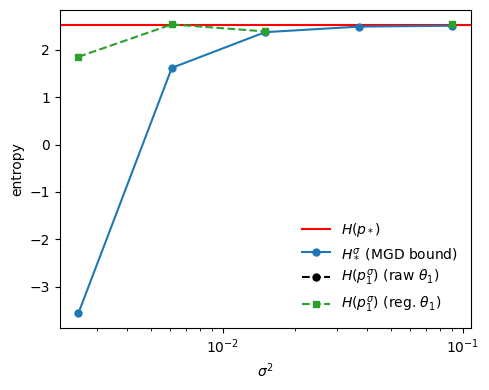

In [25]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.axhline(H_star, color='red', lw=1.5, label=r'$H(p_*)$')

ax.plot(sigmas_sorted**2, H_star_bound_mean, 'o-', color='tab:blue', ms=5,
        label=r'$H_*^\sigma$ (MGD bound)')
ax.fill_between(sigmas_sorted**2, H_star_bound_mean - H_star_bound_std,
                 H_star_bound_mean + H_star_bound_std, color='tab:blue', alpha=0.2)
claude
ax.plot(sigmas_sorted**2, H_p1_raw_mean, 'o--', color='black', ms=5,
        label=r'$H(p_1^\sigma)$ (raw $\theta_1$)')
ax.fill_between(sigmas_sorted**2, H_p1_raw_mean - H_p1_raw_std,
                 H_p1_raw_mean + H_p1_raw_std, color='black', alpha=0.15)

ax.plot(sigmas_sorted**2, H_p1_reg_mean, 's--', color='tab:green', ms=5,
        label=r'$H(p_1^\sigma)$ (reg. $\theta_1$)')
ax.fill_between(sigmas_sorted**2, H_p1_reg_mean - H_p1_reg_std,
                 H_p1_reg_mean + H_p1_reg_std, color='tab:green', alpha=0.15)

ax.set_xscale('log')
ax.set_xlabel(r'$\sigma^2$')
ax.set_ylabel('entropy')
ax.legend(frameon=False)
fig.tight_layout()

out_dir = root / 'entropy_convergence'
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / 'entropy_convergence.png', dpi=150, bbox_inches='tight')
plt.show()